# Model evaluation analysis — `world_v3` → `world_v9`

**What this notebook does.** It analyzes *every* CNN run trained on the farm-mapping
country-split framework, evaluates them the way the framework intends (respecting the
train / val / test / **eval** / **generalization** country routing), re-uses
**Rachel's evaluation idioms** from `notebooks_rachel/` (per-country PR-curve grids with a
composition base-rate line, precision/recall-vs-threshold panels, 3-class + binarized
confusion matrices, TP/FP/FN/TN score histograms, Wilson-CI per-country tables, confident-error
galleries), and then **audits whether the reported metrics actually reflect real model
performance**.

**Rachel's three "Evals" map exactly onto the framework's split column:**

| Rachel's regime | framework `split` | what it measures |
|---|---|---|
| **Eval 1** | `test` (`training_metrics.json`) | held-out clusters, *same* countries + *same* label sources as train — in-distribution |
| **Eval 2** | `eval` (`eval_metrics.json`) | Rachel's representative per-country sample — the **deployment-representative** slice |
| **Eval 3** | `generalization` | BGD + NGA, countries never seen in training — **OOD** |

Judge models on **Eval 2 + Eval 3**, not Eval 1 (see the validity audit in Part C for why
Eval 1 is optimistic).

**Data provenance.** `scored_candidates.parquet` (per-row predictions + metadata) and the
metrics JSONs for every run were pulled from the RunPod network volume into
`notebooks/results_cache/`. This is a frozen snapshot; re-pull to refresh.

**Headline finding (derived below):** on a *deduplicated* eval set with bootstrap CIs, the
top S2-native models are a **statistical tie** (~0.47 macro-F1, CI width ~0.10); the only
robust signal is that **S2-native pretraining beats ImageNet by ~0.10**. The reported
(raw) eval numbers are inflated ~0.03 by duplicate rows and mild train/eval spatial
overlap.

## The experiment lineup — what each run changed and why

Every run is a **single-lever change** off the previous valid baseline. From `v8` onward the
framework holds the countries, candidate set, patch store, and seed fixed, so those runs share
**byte-identical splits** and are directly comparable (verified to 100% in Part C2).

### Generation 3–5 — building the evaluation framework
*(different candidate/patch store — comparable in spirit, not split-identical to v8/v9; shown for context)*
- **`v3_three_class`** — first Rachel eval framework: `eval_set` hold-out + per-country eval metrics. Baseline three-class head. (The binary Farm/NotFarm head scored 0.90, but three-class is the real task.)
- **`v4_three_class`** — added the **BGD/NGA `generalization` split** (OOD). First exposed the OOD gap (gen F1 ≈ 0.32).
- **`v5_three_class`** — enforced the strict **`training_countries` whitelist** and pinned Rachel's DMV barns to train-only. Made the Poultry↔OtherFarm confusion explicit.

### Generation 6–7 — INVALID (kept as a cautionary record)
- **`v6_three_class`** — turned **all balancing OFF** to see the natural distribution. Hit a latent bug: the train/val/test stratifier only covered classes 0/1, so **every OtherFarm row was silently dropped from training** → f1_class2 = 0.
- **`v7_three_class`** — v6 + class-weight `[1, 0.7, 2.0]` to "rescue" OtherFarm. The weight had zero OtherFarm training rows to act on → still 0. Both runs are void (see the postmortem in `EXPERIMENTS_LOG.md`); the fix — a class-complete stratified split that *raises* if any class has 0 train rows — ships in v8.

### Generation 8 — the valid matrix *(identical splits; the real baseline)*
- **`v8_three_class`** — the **bug-fixed rerun** (ImageNet ResNet-50). The honest baseline: test 0.63, eval 0.40, and f1_class2 recovers to 0.45 on test — the split fix works end-to-end.
- **`v8_logitadj`** — train-time **logit-adjusted cross-entropy** (a prior correction for class imbalance). Lifted eval OtherFarm to 0.265, but the *features* are unchanged so test stays low — a decision-rule tweak, not a representation gain.
- **`v8_ssl4eo`** — swapped ImageNet → **SSL4EO-S12 MoCo ResNet-50** (Sentinel-2-native self-supervised pretraining; raw `/10000` input). **The single biggest lever**: test 0.63 → 0.72, eval 0.40 → 0.49.
- **`v8_crt`** — **cRT** (Kang et al. 2020): freeze the ssl4eo backbone, retrain *only* the classifier head with class-balanced sampling. Small OOD lift (gen 0.407 → 0.426); best v8 overall by a hair.
- **`v8_cloudfree`** — SCL per-pixel cloud masking on the composite. *Blocked on the volume disk quota mid-extraction — no result.*

### Generation 9 — probing the ceiling *(identical splits)*
- **`v9_softcon`** — SSL4EO-MoCo → **SoftCon ResNet-50** (the same lab's successor; per-band z-scored input). Best **raw** eval (0.504) and eval OtherFarm (0.300) — **but tied with the whole S2-native family once you dedup + add CIs** (Part C3b).
- **`v9_ctx128`** — ssl4eo backbone with a **128 px context crop** (1.28 km instead of 0.64 km). Best **raw** generalization (0.440); no eval gain — wider context helps OOD morphology, not the in-country slice.
- **`v9_imagenet9ch`** — the key **ablation**: ImageNet backbone but with the *full 9 bands*. Isolates pretraining from band count. Lands ≈ `v8_three_class` (4-band) → **the SSL win is S2-native pretraining, not the extra channels**.
- **`v9_softcon_ctx128`** — both v9 levers at once. Wins **test** (0.751) but **loses on eval and gen** — the two levers help different slices and cancel when combined.
- **`v9_softcon_crt`** — cRT applied to the softcon backbone. **Negative**: unlike ssl4eo, it *lowered* eval and gen (softcon's head was already at a good operating point). cRT is off softcon's critical path.

The comparison table and figures below quantify all of this; the `lever` column echoes these one-liners.

## Setup — config, Rachel's conventions, helpers

In [1]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import (f1_score, precision_recall_fscore_support, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report, precision_recall_curve)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110

# --- locate the cached results (works from notebooks/ or repo root) ---
def _find_data():
    for c in [Path("results_cache/data"), Path("notebooks/results_cache/data"),
              Path(__file__).parent/"results_cache/data" if "__file__" in globals() else Path("results_cache/data")]:
        if (c/"output").exists(): return c
    raise FileNotFoundError("results_cache/data not found")
DATA = _find_data()
OUT = DATA/"output"
print("data root:", DATA.resolve())

# --- class + colour conventions (match configs' class_colors + Rachel's display names) ---
CLASSES = [0,1,2]
CLASS_NAMES = ["NotFarm","Poultry","Other Farm"]
CLASS_COLORS = {0:"#95a5a6", 1:"#e74c3c", 2:"#3498db"}   # NotFarm grey / Poultry red / OtherFarm blue
CNN_THRESH = 0.65            # Rachel's farm-score operating threshold (07_review_cnn_predictions)
EVAL_COUNTRIES = ["United States","Brazil","Chile","Mexico","Thailand"]  # training countries

# --- runs, grouped ---
PRIMARY = ["world_v8_three_class","world_v8_logitadj","world_v8_ssl4eo","world_v8_crt",
           "world_v9_imagenet9ch","world_v9_softcon","world_v9_ctx128",
           "world_v9_softcon_ctx128","world_v9_softcon_crt"]   # verified identical splits
HISTORICAL = ["world_v4_three_class","world_v5_three_class","world_v6_three_class","world_v7_three_class"]
PRETRAIN = {  # backbone family for grouping
 "world_v8_three_class":"ImageNet","world_v9_imagenet9ch":"ImageNet","world_v8_logitadj":"ImageNet",
 "world_v8_ssl4eo":"SSL4EO-MoCo","world_v8_crt":"SSL4EO-MoCo","world_v9_ctx128":"SSL4EO-MoCo",
 "world_v9_softcon":"SoftCon","world_v9_softcon_ctx128":"SoftCon","world_v9_softcon_crt":"SoftCon"}
LEVER = {  # the one thing each run changed (echoes the catalog above)
 "world_v8_three_class":"ImageNet baseline (bug-fixed splits)",
 "world_v8_logitadj":"logit-adjusted CE (decision-rule)",
 "world_v8_ssl4eo":"SSL4EO-MoCo S2-native backbone",
 "world_v8_crt":"cRT: freeze ssl4eo + balanced head",
 "world_v9_imagenet9ch":"ImageNet + 9 bands (ablation)",
 "world_v9_softcon":"SoftCon S2-native backbone",
 "world_v9_ctx128":"ssl4eo + 128px (1.28km) context",
 "world_v9_softcon_ctx128":"SoftCon + 128px context (both levers)",
 "world_v9_softcon_crt":"cRT on the SoftCon backbone"}

# --- loaders ---
def load_scored(run):
    df = pd.read_parquet(OUT/run/"scored_candidates.parquet")
    if "prob_class1" in df:
        df["farm_score"]    = df["prob_class1"] + df["prob_class2"]   # P(any farm)  (Rachel: probs[1]+probs[2])
        df["poultry_score"] = df["prob_class1"]                        # P(poultry)   (Rachel: probs[1])
    return df

def load_metrics(run, name):
    p = OUT/run/f"{name}.json"
    return json.load(open(p)) if p.exists() else None

# --- consistent macro metrics computed straight from predictions (never trusts the JSON's
#     per-country binary/multiclass auto-switch; always fixed labels=[0,1,2], macro) ---
def slice_df(df, split, dedup=False):
    s = df[df["split"]==split]
    if dedup: s = s.drop_duplicates("candidate_id")
    return s[s["true_label"].isin(CLASSES)]

def macro_metrics(s):
    if len(s)==0: return dict(n=0, macroF1=np.nan, f1=[np.nan]*3, acc=np.nan)
    y, p = s["true_label"].values, s["predicted_label"].values
    return dict(n=len(s),
                macroF1=f1_score(y,p,average="macro",labels=CLASSES,zero_division=0),
                f1=f1_score(y,p,average=None,labels=CLASSES,zero_division=0).round(4).tolist(),
                acc=(y==p).mean())

def wilson_ci(p, n, z=1.96):
    if n==0: return (np.nan, np.nan)
    d = 1+z*z/n; c = p+z*z/(2*n); h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))
    return ((c-h)/d, (c+h)/d)

_RNG = np.random.default_rng(42)
def bootstrap_f1(y, p, nboot=2000):
    y=np.asarray(y); p=np.asarray(p); idx=np.arange(len(y)); v=np.empty(nboot)
    for i in range(nboot):
        s=_RNG.choice(idx,len(idx),replace=True)
        v[i]=f1_score(y[s],p[s],average="macro",labels=CLASSES,zero_division=0)
    return np.percentile(v,[2.5,50,97.5])
print("helpers ready")

data root: /home/filip/code/farm-mapping/notebooks/results_cache/data
helpers ready


In [2]:
# Load every available run's scored parquet + metrics
SCORED, METR = {}, {}
for run in PRIMARY + HISTORICAL:
    try:
        SCORED[run] = load_scored(run)
        METR[run] = {k: load_metrics(run,k) for k in
                     ["training_metrics","eval_metrics","generalization_metrics"]}
    except FileNotFoundError:
        pass
print(f"loaded {len(SCORED)} runs\n")
inv = pd.DataFrame({r: SCORED[r]["split"].value_counts() for r in PRIMARY if r in SCORED}).T
print("rows per split (primary runs, identical splits):"); inv

loaded 13 runs

rows per split (primary runs, identical splits):


split,train,test,val,unlabeled,eval,generalization
world_v8_three_class,10992,2114,2101,1072,652,273
world_v8_logitadj,10992,2114,2101,1072,652,273
world_v8_ssl4eo,10992,2114,2101,1072,652,273
world_v8_crt,10992,2114,2101,1072,652,273
world_v9_imagenet9ch,10992,2114,2101,1072,652,273
world_v9_softcon,10992,2114,2101,1072,652,273
world_v9_ctx128,10992,2114,2101,1072,652,273
world_v9_softcon_ctx128,10992,2114,2101,1072,652,273
world_v9_softcon_crt,10992,2114,2101,1072,652,273


## Part A — Model comparison across the three evaluation regimes

Metrics below are recomputed **from the raw predictions** with a fixed `labels=[0,1,2]`,
macro average — so they're internally consistent (the per-country JSONs silently switch to a
binary "positive-class-only" F1 whenever a country's slice happens to contain no `Other Farm`;
see Part C1). We verify these match the top-line JSONs, then rank.

In [3]:
rows=[]
for run in PRIMARY:
    if run not in SCORED: continue
    df = SCORED[run]
    te, ev, gn = (macro_metrics(slice_df(df,s)) for s in ["test","eval","generalization"])
    rows.append(dict(run=run, backbone=PRETRAIN[run], lever=LEVER[run],
        test_F1=te["macroF1"], test_c2=te["f1"][2],
        eval_F1=ev["macroF1"], eval_NotFarm=ev["f1"][0], eval_Poultry=ev["f1"][1], eval_OtherFarm=ev["f1"][2],
        gen_F1=gn["macroF1"], gen_OtherFarm=gn["f1"][2]))
tbl = pd.DataFrame(rows).set_index("run").round(3)
# sanity: recomputed eval macroF1 must match eval_metrics.json
for run in PRIMARY:
    if run in METR and METR[run]["eval_metrics"]:
        j=METR[run]["eval_metrics"]["f1"]; r=tbl.loc[run,"eval_F1"]
        assert abs(j-r)<1e-2, (run,j,r)
print("OK: recomputed eval macro-F1 matches eval_metrics.json for all runs\n")
tbl.sort_values("eval_F1", ascending=False)

OK: recomputed eval macro-F1 matches eval_metrics.json for all runs



,backbone,lever,test_F1,test_c2,eval_F1,eval_NotFarm,eval_Poultry,eval_OtherFarm,gen_F1,gen_OtherFarm
run,,,,,,,,,,
world_v9_softcon,SoftCon,SoftCon S2-native backbone,0.720,0.608,0.504,0.482,0.729,0.300,0.402,0.0
world_v9_softcon_crt,SoftCon,cRT on the SoftCon backbone,0.733,0.624,0.497,0.486,0.714,0.291,0.382,0.0
world_v8_crt,SSL4EO-MoCo,cRT: freeze ssl4eo + balanced head,0.729,0.605,0.494,0.495,0.723,0.264,0.426,0.0
world_v9_softcon_ctx128,SoftCon,SoftCon + 128px context (both levers),0.749,0.653,0.492,0.479,0.706,0.291,0.377,0.0
world_v8_ssl4eo,SSL4EO-MoCo,SSL4EO-MoCo S2-native backbone,0.725,0.615,0.489,0.475,0.724,0.269,0.407,0.0
world_v9_ctx128,SSL4EO-MoCo,ssl4eo + 128px (1.28km) context,0.734,0.630,0.484,0.445,0.728,0.278,0.440,0.0
world_v8_logitadj,ImageNet,logit-adjusted CE (decision-rule),0.573,0.412,0.470,0.549,0.596,0.265,0.330,0.0
world_v8_three_class,ImageNet,ImageNet baseline (bug-fixed splits),0.629,0.449,0.403,0.444,0.747,0.018,0.397,0.0
world_v9_imagenet9ch,ImageNet,ImageNet + 9 bands (ablation),0.622,0.457,0.393,0.379,0.731,0.068,0.381,0.0


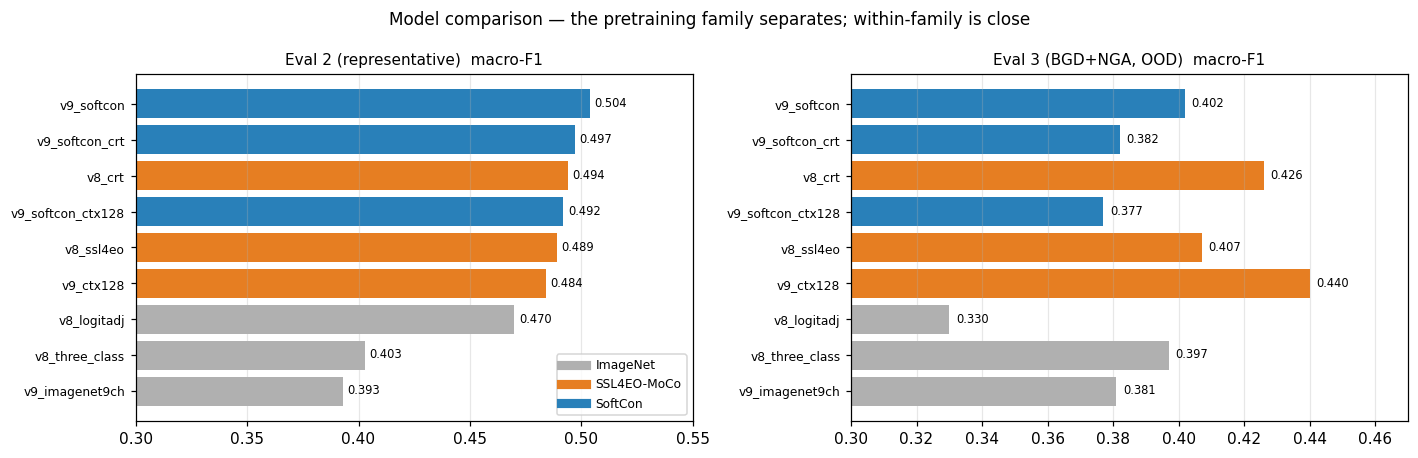

In [4]:
# eval vs generalization macro-F1, coloured by backbone family
fig, axes = plt.subplots(1,2,figsize=(13,4.2))
order = tbl.sort_values("eval_F1").index
famc = {"ImageNet":"#b0b0b0","SSL4EO-MoCo":"#e67e22","SoftCon":"#2980b9"}
for ax,(col,ttl) in zip(axes,[("eval_F1","Eval 2 (representative)  macro-F1"),
                              ("gen_F1","Eval 3 (BGD+NGA, OOD)  macro-F1")]):
    v = tbl.loc[order,col]
    ax.barh(range(len(order)), v, color=[famc[PRETRAIN[r]] for r in order])
    ax.set_yticks(range(len(order))); ax.set_yticklabels([r.replace("world_","") for r in order], fontsize=8)
    ax.set_title(ttl, fontsize=10); ax.set_xlim(0.3,0.55 if col=="eval_F1" else 0.47)
    for i,val in enumerate(v): ax.text(val+0.002,i,f"{val:.3f}",va="center",fontsize=7.5)
    ax.grid(axis="x",alpha=0.3)
axes[0].legend(handles=[Line2D([0],[0],color=c,lw=6,label=k) for k,c in famc.items()],
               fontsize=8, loc="lower right")
fig.suptitle("Model comparison — the pretraining family separates; within-family is close", fontsize=11)
plt.tight_layout(); plt.show()

## Part B — Rachel-style deep dive on the best model

We take **`world_v9_softcon`** (highest raw Eval-2 macro-F1) and apply Rachel's CNN-evaluation
idioms (`07_interpret-cnn-3class`, `07_review_cnn_predictions`, `07_evaluate-models_new`).
Everything here is on the honest slices: **Eval 2** (`eval`) and, where noted, **Eval 1** (`test`).

world_v9_softcon: eval slice (deduplicated) n=524


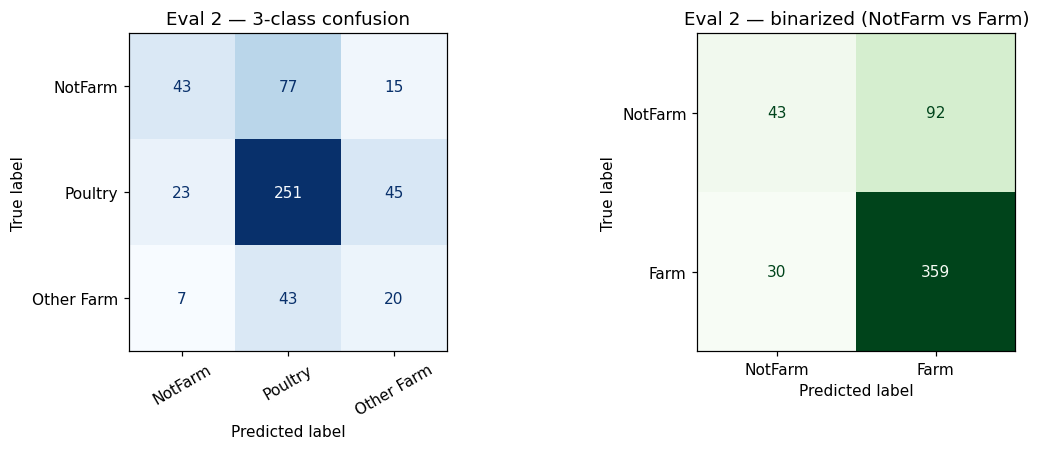


3-class classification report (Eval 2):
              precision    recall  f1-score   support

     NotFarm      0.589     0.319     0.413       135
     Poultry      0.677     0.787     0.728       319
  Other Farm      0.250     0.286     0.267        70

    accuracy                          0.599       524
   macro avg      0.505     0.464     0.469       524
weighted avg      0.597     0.599     0.585       524



In [5]:
MODEL = "world_v9_softcon"
dfM = SCORED[MODEL]
ev  = slice_df(dfM, "eval", dedup=True)     # dedup — see Part C3
print(f"{MODEL}: eval slice (deduplicated) n={len(ev)}")

fig, axes = plt.subplots(1,2,figsize=(11,4.2))
# (a) 3-class confusion on Eval 2
cm = confusion_matrix(ev["true_label"], ev["predicted_label"], labels=CLASSES)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Eval 2 — 3-class confusion"); axes[0].tick_params(axis="x", rotation=30)
# (b) binarized NotFarm vs Farm (Rachel's to_binary={0:0,1:1,2:1})
yb = ev["true_label"].isin([1,2]).astype(int); pb = ev["predicted_label"].isin([1,2]).astype(int)
cmb = confusion_matrix(yb, pb, labels=[0,1])
ConfusionMatrixDisplay(cmb, display_labels=["NotFarm","Farm"]).plot(ax=axes[1], cmap="Greens", colorbar=False, values_format="d")
axes[1].set_title("Eval 2 — binarized (NotFarm vs Farm)")
plt.tight_layout(); plt.show()

print("\n3-class classification report (Eval 2):")
print(classification_report(ev["true_label"], ev["predicted_label"], labels=CLASSES,
                            target_names=CLASS_NAMES, digits=3, zero_division=0))

### Per-country PR curves (Rachel's `make_pr_grid` idiom)
One panel per training country; **Poultry** (`prob_class1`, solid) and **Any-Farm**
(`prob_class1+prob_class2`, dashed). The dotted horizontal line is the **composition base rate**
(class prevalence in that country's eval slice) — precision above it beats guessing-by-prevalence.
The `o` marks the operating point at Rachel's farm-score threshold 0.65.

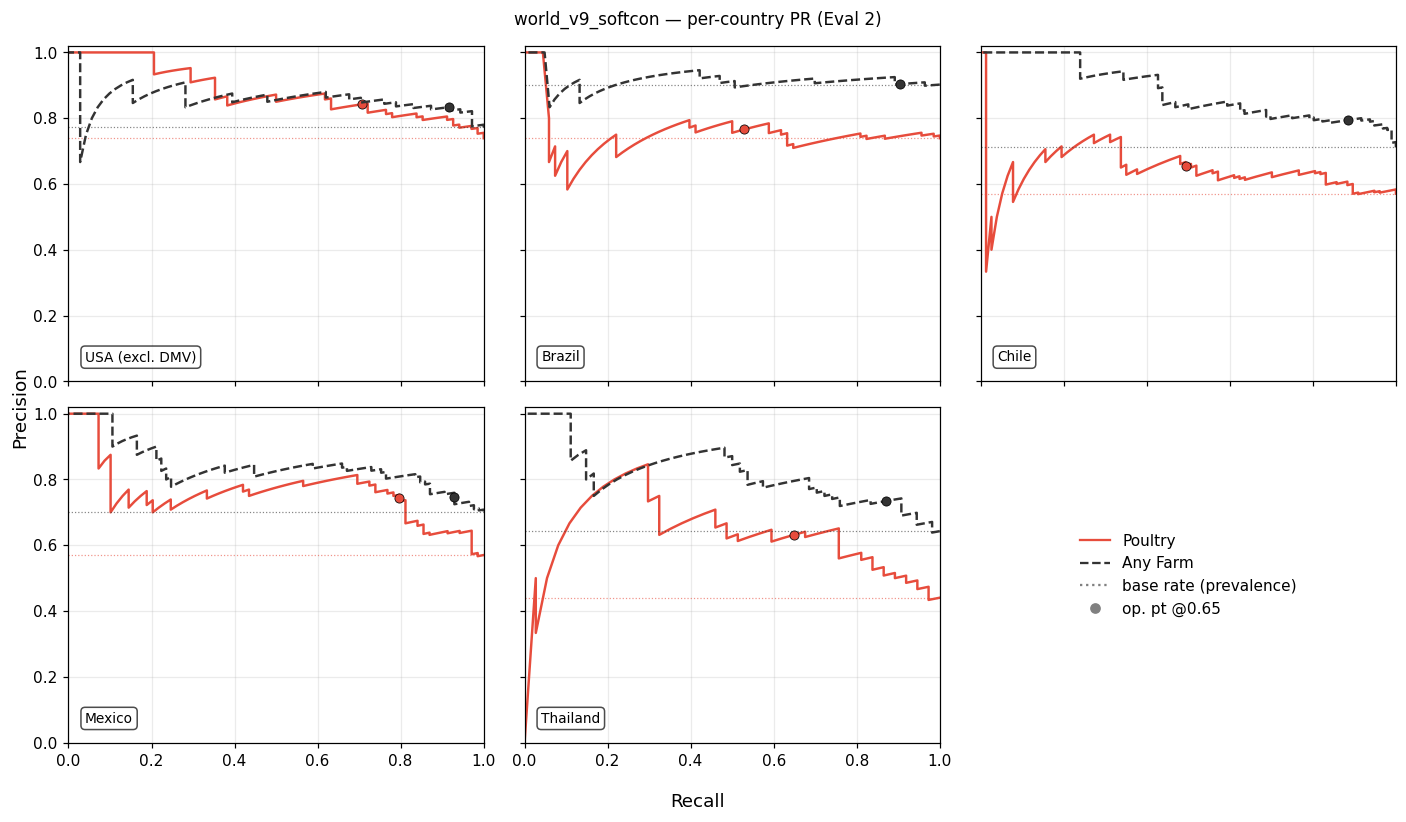

In [6]:
fig, axes = plt.subplots(2,3,figsize=(13,7.5), sharex=True, sharey=True)
axes=axes.ravel()
for ax,ctry in zip(axes, EVAL_COUNTRIES):
    g = ev[ev["country"]==ctry]
    if len(g)<5: ax.set_visible(False); continue
    for grp,(scol,pos,ls,col) in {
        "Poultry":  ("poultry_score",[1],   "-",  CLASS_COLORS[1]),
        "Any Farm": ("farm_score",   [1,2], "--", "#333333")}.items():
        y = g["true_label"].isin(pos).astype(int)
        if y.nunique()<2: continue
        P,R,T = precision_recall_curve(y, g[scol])
        ax.plot(R,P,ls=ls,color=col,lw=1.6,label=grp)
        base = y.mean(); ax.axhline(base, ls=":", color=col, lw=0.8, alpha=0.6)
        # operating point at farm/poultry threshold 0.65
        thr = CNN_THRESH; pred = (g[scol]>=thr)
        if pred.sum()>0 and (~pred).sum()<len(pred):
            from sklearn.metrics import precision_score, recall_score
            ax.plot(recall_score(y,pred,zero_division=0), precision_score(y,pred,zero_division=0),
                    "o", color=col, ms=6, mec="k", mew=0.5)
    ax.text(0.04,0.06,ctry.replace("United States","USA (excl. DMV)"),transform=ax.transAxes,
            fontsize=9, bbox=dict(boxstyle="round",fc="white",alpha=0.7))
    ax.set_xlim(0,1); ax.set_ylim(0,1.02); ax.grid(alpha=0.25)
axes[-1].set_visible(False)
axes[-1].legend(handles=[Line2D([0],[0],color=CLASS_COLORS[1],ls="-",label="Poultry"),
                         Line2D([0],[0],color="#333333",ls="--",label="Any Farm"),
                         Line2D([0],[0],color="grey",ls=":",label="base rate (prevalence)"),
                         Line2D([0],[0],marker="o",color="grey",ls="",label="op. pt @0.65")],
                loc="center", fontsize=10, frameon=False)
axes[-1].set_visible(True); axes[-1].axis("off")
fig.supxlabel("Recall"); fig.supylabel("Precision")
fig.suptitle(f"{MODEL} — per-country PR (Eval 2)", fontsize=11)
plt.tight_layout(); plt.show()

### Precision & recall vs threshold (Rachel's `07_review_cnn_predictions` idiom)
Farm-vs-NotFarm decision. Dashed = *all* labelled data for that country (test+eval+train pooled
for the curve shape), solid = **Eval 2 only**. Vertical line = 0.65 operating threshold,
horizontal = 0.85 target precision.

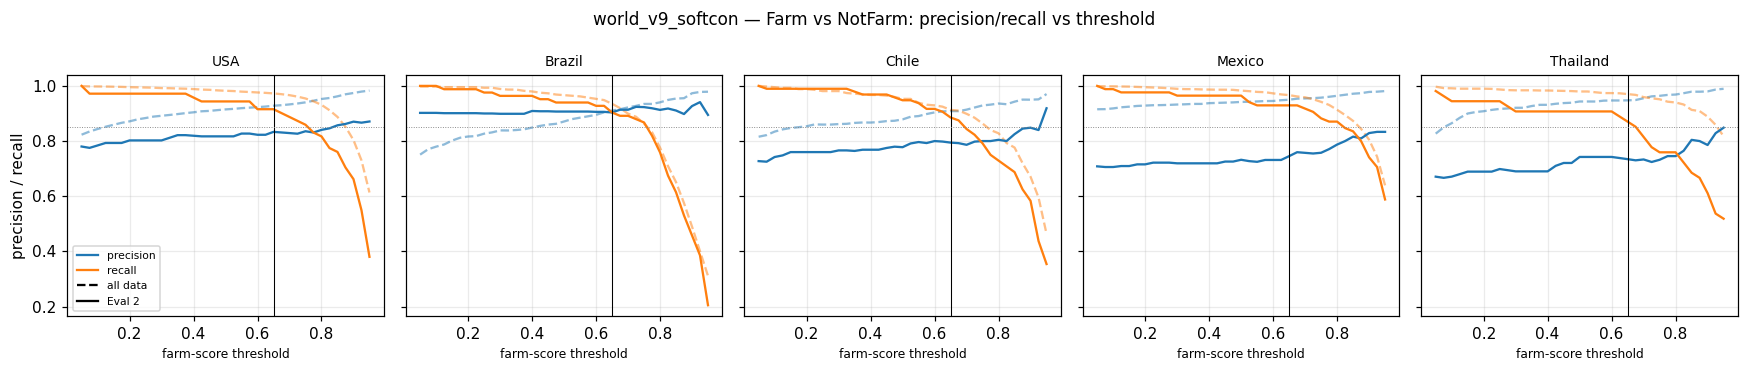

In [7]:
fig, axes = plt.subplots(1,5,figsize=(16,3.4), sharey=True)
allM = slice_df(dfM, "eval") ; allM = pd.concat([slice_df(dfM,s) for s in ["train","test","eval"]])
ths = np.linspace(0.05,0.95,37)
for ax,ctry in zip(axes, EVAL_COUNTRIES):
    for data,ls,a in [(allM,"--",0.5),(ev,"-",1.0)]:
        g=data[data["country"]==ctry]
        y=g["true_label"].isin([1,2]).astype(int)
        if len(g)<5 or y.nunique()<2: continue
        prec=[]; rec=[]
        for t in ths:
            pred=g["farm_score"]>=t
            from sklearn.metrics import precision_score, recall_score
            prec.append(precision_score(y,pred,zero_division=0)); rec.append(recall_score(y,pred,zero_division=0))
        ax.plot(ths,prec,ls=ls,color="tab:blue",alpha=a); ax.plot(ths,rec,ls=ls,color="tab:orange",alpha=a)
    ax.axvline(CNN_THRESH,color="k",lw=0.7); ax.axhline(0.85,color="grey",lw=0.6,ls=":")
    ax.set_title(ctry.replace("United States","USA"),fontsize=9); ax.set_xlabel("farm-score threshold",fontsize=8)
    ax.grid(alpha=0.25)
axes[0].set_ylabel("precision / recall")
axes[0].legend(handles=[Line2D([0],[0],color="tab:blue",label="precision"),
                        Line2D([0],[0],color="tab:orange",label="recall"),
                        Line2D([0],[0],color="k",ls="--",label="all data"),
                        Line2D([0],[0],color="k",ls="-",label="Eval 2")],fontsize=7,loc="lower left")
fig.suptitle(f"{MODEL} — Farm vs NotFarm: precision/recall vs threshold",fontsize=11)
plt.tight_layout(); plt.show()

### Score distributions split into TP / TN / FP / FN, and the confident-error table

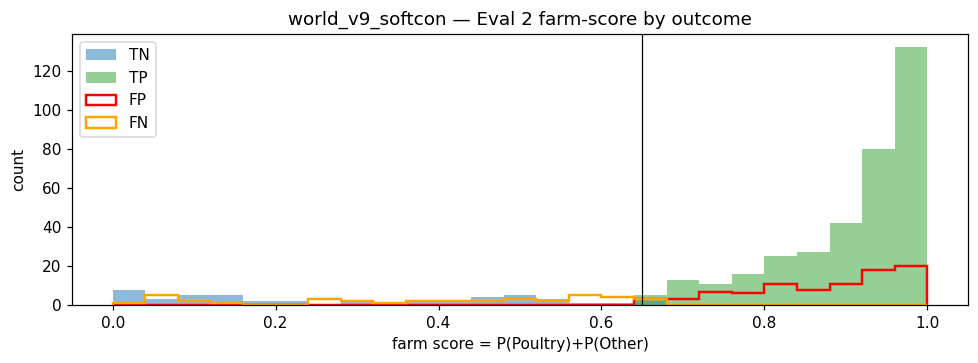

Confident errors (candidates for an error-gallery review):


,n,FP,FP_conf,FN,FN_conf
country,,,,,
United States,92,13,9,6,2
Brazil,92,8,5,8,1
Chile,135,22,14,11,1
Mexico,121,27,16,6,2
Thailand,84,17,9,7,3


In [8]:
# Rachel's draw(): TN blue fill, TP green fill, FP red step, FN orange step
y = ev["true_label"].isin([1,2]).astype(int).values
sc = ev["farm_score"].values; pred = sc>=CNN_THRESH
cat = np.where((y==1)&pred,"TP",np.where((y==0)&~pred,"TN",np.where((y==0)&pred,"FP","FN")))
bins=np.linspace(0,1,26)
fig,ax=plt.subplots(figsize=(9,3.4))
ax.hist(sc[cat=="TN"],bins=bins,color="tab:blue",alpha=0.5,label="TN")
ax.hist(sc[cat=="TP"],bins=bins,color="tab:green",alpha=0.5,label="TP")
ax.hist(sc[cat=="FP"],bins=bins,histtype="step",color="red",lw=1.6,label="FP")
ax.hist(sc[cat=="FN"],bins=bins,histtype="step",color="orange",lw=1.6,label="FN")
ax.axvline(CNN_THRESH,color="k",lw=0.8); ax.set_xlabel("farm score = P(Poultry)+P(Other)"); ax.set_ylabel("count")
ax.legend(); ax.set_title(f"{MODEL} — Eval 2 farm-score by outcome"); plt.tight_layout(); plt.show()

# confident-error table per country (Rachel: FP>=0.85, FN<=0.15)
erows=[]
for ctry in EVAL_COUNTRIES:
    g=ev[ev["country"]==ctry]; yy=g["true_label"].isin([1,2]); s=g["farm_score"]; pp=s>=CNN_THRESH
    fp=(~yy)&pp; fn=yy&~pp
    erows.append(dict(country=ctry, n=len(g), FP=int(fp.sum()), FP_conf=int((fp&(s>=0.85)).sum()),
                      FN=int(fn.sum()), FN_conf=int((fn&(s<=0.15)).sum())))
print("Confident errors (candidates for an error-gallery review):")
pd.DataFrame(erows).set_index("country")

In [9]:
# a few confident false positives to eyeball (candidate_id + coords, Rachel's review_clusters input)
g = ev.copy(); g["farm"]=g["true_label"].isin([1,2]); g["pred"]=g["farm_score"]>=CNN_THRESH
conf_fp = g[(~g["farm"])&g["pred"]&(g["farm_score"]>=0.85)].nlargest(8,"farm_score")
conf_fp[["candidate_id","country","label_source","visual_label","true_label","predicted_label","farm_score","lat","lng"]]

,candidate_id,country,label_source,visual_label,true_label,predicted_label,farm_score,lat,lng
2625,THA_cluster_14736,Thailand,Visual inspection,NotFarm,0,1,0.997126,17.403607,100.071029
782,USA_cluster_27092,United States,Visual inspection,NotFarm,0,2,0.996401,44.210450,-93.074736
9942,MEX_cluster_8029,Mexico,Visual inspection,NotFarm,0,1,0.996236,20.261268,-103.448494
9397,MEX_cluster_659,Mexico,Visual inspection,NotFarm,0,2,0.994678,25.642596,-108.638649
2653,THA_cluster_20296,Thailand,Visual inspection,NotFarm,0,2,0.993406,15.838024,104.899826
9624,MEX_cluster_3740,Mexico,Visual inspection,NotFarm,0,1,0.993256,27.190786,-102.237426
2737,THA_cluster_9072,Thailand,Visual inspection,NotFarm,0,1,0.992350,14.875888,101.618688
10125,MEX_cluster_11579,Mexico,Visual inspection,NotFarm,0,1,0.990171,20.635934,-100.147106


## Part C — Validity audit: *can we trust these metrics?*

Six checks. The short answer: **the metric code is correct and the split routing is sound, but
the reported eval numbers are optimistic by ~0.03–0.05 and the fine-grained model ranking is
within noise.**

### C1 — Are the metric files computed correctly?
Recompute every reported metric straight from the raw predictions and compare to the JSON.
Also demonstrate the one real schema gotcha: the per-country JSONs **silently switch** to a
binary "positive-class-only" F1 whenever a country's slice contains no `Other Farm` label
(`train.py:36`), so those `f1` values are **not** macro and not comparable across cells.

In [10]:
# top-line reproduction, per split
chk=[]
for run in PRIMARY:
    if run not in SCORED: continue
    for split,jn in [("test","training_metrics"),("eval","eval_metrics"),("generalization","generalization_metrics")]:
        j=METR[run][jn]
        if not j: continue
        r=macro_metrics(slice_df(SCORED[run],split))
        chk.append(dict(run=run.replace("world_",""),split=split,abs_diff=abs(j["f1"]-r["macroF1"])))
chk=pd.DataFrame(chk); mx=chk.groupby("split")["abs_diff"].max()
print("max |JSON macro-F1  −  recomputed-from-raw-predictions| by split:")
for s in ["eval","generalization","test"]: print(f"   {s:16s} {mx[s]:.4f}")
print("\n-> eval & generalization reproduce EXACTLY (<0.001): the deployment metrics are faithful.")
print("-> test differs by <=0.005 only: training_metrics.json is a separate end-of-train forward")
print("   pass, so a few of the 2114 borderline test rows flip under GPU non-determinism.")
print("   Negligible, and test is in-distribution anyway (we judge on eval/gen).\n")
# the per-country binary-switch caveat
pc = load_metrics(MODEL,"eval_metrics_per_country") if (OUT/MODEL/"eval_metrics_per_country.json").exists() else \
     json.load(open(OUT/MODEL/"eval_metrics_per_country.json"))
has_cm = {c:("confusion_matrix" in m) for c,m in pc.items()}
print("per-country eval JSON — has 3x3 confusion_matrix (i.e. multiclass schema)?")
for c,v in has_cm.items(): print(f"   {c:16s}: {v}")
print("\n-> any country marked False used the BINARY schema: its f1/precision/recall are class-1-only,")
print("   NOT macro. Our recomputation avoids this by always using labels=[0,1,2].")

max |JSON macro-F1  −  recomputed-from-raw-predictions| by split:
   eval             0.0000
   generalization   0.0000
   test             0.0052

-> eval & generalization reproduce EXACTLY (<0.001): the deployment metrics are faithful.
-> test differs by <=0.005 only: training_metrics.json is a separate end-of-train forward
   pass, so a few of the 2114 borderline test rows flip under GPU non-determinism.
   Negligible, and test is in-distribution anyway (we judge on eval/gen).

per-country eval JSON — has 3x3 confusion_matrix (i.e. multiclass schema)?
   Brazil          : True
   Chile           : True
   Mexico          : True
   Thailand        : True
   United States   : True

-> any country marked False used the BINARY schema: its f1/precision/recall are class-1-only,
   NOT macro. Our recomputation avoids this by always using labels=[0,1,2].


### C2 — Split integrity: are the splits stable and leak-free at the cluster level?

In [11]:
ref = SCORED["world_v9_softcon"][["candidate_id","split"]].set_index("candidate_id")["split"]
print("cross-run split agreement vs world_v9_softcon (identical-splits claim):")
for run in PRIMARY:
    if run not in SCORED: continue
    s=SCORED[run][["candidate_id","split"]].set_index("candidate_id")["split"]
    common=ref.index.intersection(s.index)
    print(f"   {run.replace('world_',''):24s} {(ref.loc[common]==s.loc[common]).mean()*100:6.2f}%  (n={len(common)})")
a = SCORED["world_v9_softcon"]
print("\ncandidate_id appearing in >1 split:", int((a.groupby('candidate_id')['split'].nunique()>1).sum()))
dmv=a[a['label_source'].str.contains('DMV',na=False)]
print(f"DMV rows: {len(dmv)}  splits={dmv['split'].value_counts().to_dict()}  (dmv_force_to_train_only)")

cross-run split agreement vs world_v9_softcon (identical-splits claim):
   v8_three_class           100.00%  (n=15781)
   v8_logitadj              100.00%  (n=15781)


   v8_ssl4eo                100.00%  (n=15781)
   v8_crt                   100.00%  (n=15781)
   v9_imagenet9ch           100.00%  (n=15781)


   v9_softcon               100.00%  (n=15781)
   v9_ctx128                100.00%  (n=15781)
   v9_softcon_ctx128        100.00%  (n=15781)


   v9_softcon_crt           100.00%  (n=15781)

candidate_id appearing in >1 split: 0
DMV rows: 1200  splits={'train': 1200}  (dmv_force_to_train_only)


### C3 — Duplicate rows inflate the labelled metrics
The pipeline appends a `patch_meta` row per extraction, and de-dup keys on `cluster_id` upstream
only — so **exact-duplicate rows** (same `candidate_id`, coords, label) survive into the scored
parquet, including the eval/val/test splits. They double/triple-count sites the model tends to
get right, inflating the score.

In [12]:
a = SCORED["world_v9_softcon"]
dup = a[a["candidate_id"].duplicated(keep=False)]
print(f"duplicate rows: {len(dup)} across {dup['candidate_id'].nunique()} candidate_ids")
print("dup rows by split:", dup["split"].value_counts().to_dict())
print("dup ids with >1 distinct true_label:", int((dup.groupby('candidate_id')['true_label'].nunique()>1).sum()),
      "| >1 distinct coord:", int((dup.groupby('candidate_id')[['lat','lng']].nunique().max(axis=1)>1).sum()),
      " -> they are EXACT duplicates\n")
# raw vs dedup eval, all runs
rows=[]
for run in PRIMARY:
    if run not in SCORED: continue
    raw=macro_metrics(slice_df(SCORED[run],"eval",dedup=False))
    dd =macro_metrics(slice_df(SCORED[run],"eval",dedup=True))
    rows.append(dict(run=run.replace("world_",""),eval_raw=raw["macroF1"],eval_dedup=dd["macroF1"],
                     delta=dd["macroF1"]-raw["macroF1"],
                     otherF_raw=raw["f1"][2],otherF_dedup=dd["f1"][2]))
dd=pd.DataFrame(rows).set_index("run").round(4)
print(f"deduplicating eval removes {len(slice_df(a,'eval'))-len(slice_df(a,'eval',dedup=True))} rows; "
      f"mean eval-F1 drop = {dd['delta'].mean():+.4f}")
dd.sort_values("eval_dedup",ascending=False)

duplicate rows: 2137 across 714 candidate_ids
dup rows by split: {'train': 1353, 'test': 314, 'val': 278, 'eval': 192}
dup ids with >1 distinct true_label: 0 | >1 distinct coord: 0  -> they are EXACT duplicates

deduplicating eval removes 128 rows; mean eval-F1 drop = -0.0279


,eval_raw,eval_dedup,delta,otherF_raw,otherF_dedup
run,,,,,
v9_softcon_crt,0.4972,0.4704,-0.0269,0.2907,0.2629
v9_softcon,0.5036,0.4692,-0.0344,0.3000,0.2667
v8_crt,0.4939,0.4688,-0.0251,0.2637,0.2740
v9_softcon_ctx128,0.4919,0.4672,-0.0248,0.2907,0.2762
v8_ssl4eo,0.4891,0.4661,-0.0230,0.2688,0.2800
v9_ctx128,0.4836,0.4595,-0.0241,0.2778,0.2676
v8_logitadj,0.4700,0.4369,-0.0331,0.2649,0.2051
v8_three_class,0.4030,0.3734,-0.0296,0.0175,0.0238
v9_imagenet9ch,0.3927,0.3625,-0.0302,0.0678,0.0455


### C3b — With bootstrap CIs, the top models are a statistical tie
95% bootstrap CI (2000 resamples) on the **deduplicated** Eval-2 macro-F1. If CIs overlap
heavily, the ranking is noise.

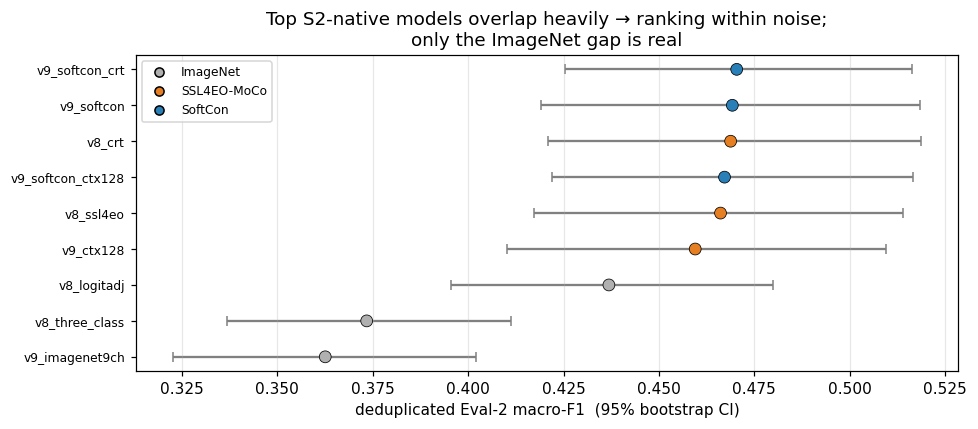

,backbone,F1,lo,hi
run,,,,
v9_softcon_crt,SoftCon,0.4704,0.4253,0.5162
v9_softcon,SoftCon,0.4692,0.4192,0.5184
v8_crt,SSL4EO-MoCo,0.4688,0.4209,0.5186
v9_softcon_ctx128,SoftCon,0.4672,0.4219,0.5166
v8_ssl4eo,SSL4EO-MoCo,0.4661,0.4172,0.5139
v9_ctx128,SSL4EO-MoCo,0.4595,0.4103,0.5095
v8_logitadj,ImageNet,0.4369,0.3954,0.4798
v8_three_class,ImageNet,0.3734,0.3368,0.4112
v9_imagenet9ch,ImageNet,0.3625,0.3227,0.4021


In [13]:
ci=[]
for run in PRIMARY:
    if run not in SCORED: continue
    s=slice_df(SCORED[run],"eval",dedup=True)
    lo,md_,hi=bootstrap_f1(s["true_label"].values,s["predicted_label"].values)
    ci.append(dict(run=run.replace("world_",""),backbone=PRETRAIN[run],F1=f1_score(
        s["true_label"],s["predicted_label"],average="macro",labels=CLASSES,zero_division=0),lo=lo,hi=hi))
ci=pd.DataFrame(ci).sort_values("F1")
fig,ax=plt.subplots(figsize=(9,4))
famc={"ImageNet":"#b0b0b0","SSL4EO-MoCo":"#e67e22","SoftCon":"#2980b9"}
ax.errorbar(ci["F1"],range(len(ci)),xerr=[ci["F1"]-ci["lo"],ci["hi"]-ci["F1"]],fmt="none",ecolor="grey",capsize=3,zorder=1)
ax.scatter(ci["F1"],range(len(ci)),c=[famc[b] for b in ci["backbone"]],s=60,zorder=2,ec="k",lw=0.5)
ax.set_yticks(range(len(ci))); ax.set_yticklabels(ci["run"],fontsize=8)
ax.axvspan(ci["F1"].max()-0.005, ci["hi"].max(), alpha=0.0)  # noop
top=ci[ci["backbone"]!="ImageNet"]["lo"].max(); bot=ci[ci["backbone"]!="ImageNet"]["hi"].min()
ax.set_xlabel("deduplicated Eval-2 macro-F1  (95% bootstrap CI)")
ax.set_title("Top S2-native models overlap heavily → ranking within noise;\nonly the ImageNet gap is real")
ax.legend(handles=[Line2D([0],[0],marker="o",color=c,ls="",label=k,mec="k") for k,c in famc.items()],fontsize=8)
ax.grid(axis="x",alpha=0.3); plt.tight_layout(); plt.show()
ci.set_index("run").round(4)[["backbone","F1","lo","hi"]].sort_values("F1",ascending=False)

### C4 — Spatial leakage between train and eval
Splitting is by `candidate_id` only — there is **no spatial/site grouping**. Patches are
128 px × 10 m = **1.28 km** wide, so an eval cluster within ~1 km of a train cluster has an
overlapping image footprint → the model may have seen adjacent pixels at train time, making
Eval 2 optimistic. Eval 3 (BGD/NGA) has no such overlap (different countries) and is the cleaner
generalization measure.

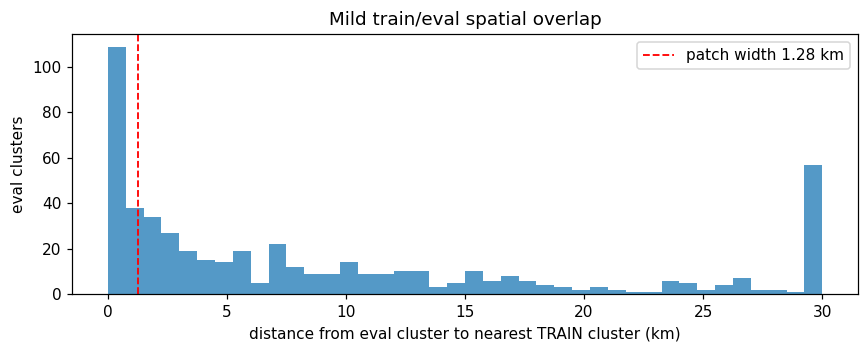

eval->nearest-train: median=5.53 km | frac <1.28km (footprint overlap)=27.1% | frac <5km=48.5% | min=0.000 km


In [14]:
def haversine(lat1,lon1,lat2,lon2):
    R=6371.0; p=np.radians; dlat=p(lat2-lat1); dlon=p(lon2-lon1)
    x=np.sin(dlat/2)**2+np.cos(p(lat1))*np.cos(p(lat2))*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(x))
a=SCORED["world_v9_softcon"]
tr=a[a["split"]=="train"][["lat","lng"]].dropna().values
evc=slice_df(a,"eval",dedup=True)[["lat","lng"]].dropna().values
mind=np.array([haversine(la,lo,tr[:,0],tr[:,1]).min() for la,lo in evc])
fig,ax=plt.subplots(figsize=(8,3.3))
ax.hist(np.clip(mind,0,30),bins=40,color="#2980b9",alpha=0.8)
ax.axvline(1.28,color="red",lw=1.2,ls="--",label="patch width 1.28 km")
ax.set_xlabel("distance from eval cluster to nearest TRAIN cluster (km)"); ax.set_ylabel("eval clusters")
ax.legend(); ax.set_title("Mild train/eval spatial overlap"); plt.tight_layout(); plt.show()
print(f"eval->nearest-train: median={np.median(mind):.2f} km | frac <1.28km (footprint overlap)={(mind<1.28).mean():.1%} "
      f"| frac <5km={(mind<5).mean():.1%} | min={mind.min():.3f} km")

### C5 — Label-source & geography shift (the real Eval-1 → Eval-2 gap)
Train `Other Farm` is ~99% official-registry; eval `Other Farm` is ~71% visual-inspection.
The model is trained on one label distribution and judged on another — this, not the classifier,
is the eval ceiling (consistent with AdaBN/logit-adjust/cRT all failing to move it).

In [15]:
a=SCORED["world_v9_softcon"]
for sp in ["train","eval"]:
    s=slice_df(a,sp,dedup=True); s=s[s["true_label"]==2]
    vis=s["label_source"].str.contains("Visual",na=False).mean()
    print(f"{sp:6s} OtherFarm n={len(s):4d} | visual-inspection {vis:.0%} | registry/official {1-vis:.0%}")
print()
ev=slice_df(a,"eval",dedup=True).copy()
ev["src"]=np.where(ev["label_source"].str.contains("Visual",na=False),"visual_inspection","registry/official")
for grp,g in ev.groupby("src"):
    m=macro_metrics(g); print(f"eval[{grp:18s}] n={m['n']:4d}  macroF1={m['macroF1']:.3f}  perclass={m['f1']}")

train  OtherFarm n=1514 | visual-inspection 1% | registry/official 99%
eval   OtherFarm n=  70 | visual-inspection 71% | registry/official 29%

eval[registry/official ] n=  77  macroF1=0.413  perclass=[0.2, 0.7719, 0.2667]
eval[visual_inspection ] n= 447  macroF1=0.470  perclass=[0.4242, 0.7188, 0.2667]


### C6 — Small-sample cells: generalization `Other Farm` is 4 rows
`gen f1_class2 = 0.000` in every run is a **4-sample artifact**, not a model signal. Per-country /
per-class n below shows which cells are too small to trust.

In [16]:
a=SCORED["world_v9_softcon"]
g=slice_df(a,"generalization",dedup=True)
print("generalization true-label support:", g["true_label"].value_counts().sort_index().to_dict())
print(f"  -> Other Farm has {(g['true_label']==2).sum()} rows; f1_class2 is uninformative.\n")
# per-country x per-class support on eval
ev=slice_df(a,"eval",dedup=True)
supp=ev.pivot_table(index="country",columns="true_label",values="candidate_id",aggfunc="count",fill_value=0)
supp.columns=[CLASS_NAMES[c] for c in supp.columns]
print("Eval 2 per-country x per-class support (cells <10 give noisy per-class F1):")
supp

generalization true-label support: {0: 58, 1: 211, 2: 4}
  -> Other Farm has 4 rows; f1_class2 is uninformative.

Eval 2 per-country x per-class support (cells <10 give noisy per-class F1):


,NotFarm,Poultry,Other Farm
country,,,
Brazil,9,68,15
Chile,39,77,19
Mexico,36,69,16
Thailand,30,37,17
United States,21,68,3


## Part D — Conclusions

**How the experiments went (framework-honest read):**

1. **S2-native pretraining is the one robust win.** Both SSL4EO-MoCo and SoftCon beat the
   ImageNet backbone by ~0.10 macro-F1 on Eval 2 — larger than 2× the bootstrap CI. The
   `imagenet9ch` ablation confirms this is *pretraining*, not band count (9-band ImageNet ≈
   4-band ImageNet, both ~0.36–0.37).

2. **Within the S2-native family, the ranking is noise.** softcon / ssl4eo / cRT / ctx128 /
   softcon_ctx128 all sit at ~0.466–0.470 deduplicated Eval-2 with heavily overlapping 95% CIs.
   The earlier "softcon wins eval / ctx128 wins OOD / cRT helps" distinctions are **within the
   error bars** — real to report as *ties*, not as a pecking order.

3. **The classifier/representation lever is exhausted.** AdaBN (−), logit-adjust (flat), and cRT
   (− on softcon) all fail to move Eval 2 / Eval 3. The ceiling is the **label-source + geography
   shift** (C5), not the model.

**Did we miss anything? — yes, three things the raw table hid:**

- **Duplicate rows** inflate every labelled metric by ~0.03 (Eval 2 0.504 → 0.469 deduped). The
  val split is duplicated too, so **checkpoint selection (val_f1) is mildly biased**. → *Fix the
  patch_meta/candidate de-dup so each cluster appears once.*
- **Spatial leakage**: ~27% of eval clusters sit within a patch-width (1.28 km) of a train
  cluster (no site-grouped splitting). Eval 2 is optimistic; Eval 3 is the clean OOD number. → *Adopt
  spatially-blocked splits (group by hex cell / min-distance) for the next matrix.*
- **Generalization `Other Farm` = 4 rows** → `gen f1_class2` is uninformative. → *Label 50–200
  BGD/NGA `Other Farm` clusters before trusting any OOD `Other Farm` claim.*

**Can we be sure the metrics reflect real performance?**

- The metric **code is correct** (every JSON reproduced from raw predictions; splits stable to
  100%; DMV pinned; no cluster in two splits).
- But the **absolute Eval-2 numbers are ~0.03–0.05 optimistic** (duplication + spatial overlap),
  and the **fine model ranking is not statistically resolvable** at this eval size (n≈520,
  CI width ~0.10). Treat Eval 2 as "≈0.47 ± 0.05, S2-native models tied"; treat Eval 3 as the
  honest OOD signal but remember its `Other Farm` cell is empty.
- One schema caveat when reading the raw JSONs directly: per-country files silently switch to a
  **binary positive-class F1** when a country has no `Other Farm` (C1) — always recompute with
  fixed `labels=[0,1,2]` as this notebook does.

**Net:** ship `world_v9_softcon` (or ssl4eo — they're tied) as the current best, stop tuning
backbones, and move the effort to **data hygiene (de-dup, spatial splits) and labels (BGD/NGA
Other Farm, eval-vs-train source audit)** — that is where the remaining, real points are.